In [1]:
import openeo
from openeo.processes import quantiles

from shapely.geometry import shape

import xarray as xr
import os
import rasterio
import glob

In [2]:
connection = openeo.connect(url="openeo.dataspace.copernicus.eu")
connection.authenticate_oidc()

Authenticated using refresh token.


<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

## Sentinel-2 mosaic from Sentinel-2 L2A

Create the Sentinel-2 mosaic from L2A data. Product description: 

https://dataspace.copernicus.eu/news/2024-2-27-exploring-new-frontier-sentinel-cloudless-mosaics-copernicus-data-space-ecosystem

https://documentation.dataspace.copernicus.eu/Data/SentinelMissions/Sentinel2.html#sentinel-2-level-3-quarterly-mosaics

In [3]:
spatial_extent_west = {"west": 610950, "east": 674650, "south": 5143820, "north": 5206380, "crs": "EPSG:32632"} # Western South Tyrol glaciers
spatial_extent_east = {"west": 704100, "east": 747040, "south": 5195880, "north": 5219660, "crs": "EPSG:32632"} # Eastern South Tyrol glaciers

In [4]:
temporal_extent = ["2017-07-01T00:00:00Z", "2017-09-30T23:59:59Z"]

from pathlib import Path
output_folder = Path("/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests")

### 1) Generate the Sentinel-2 L2A cube

Load all the 10 m resolution bands + SCL

In [5]:
def load_s2(spatial_extent):
    s2_cube = connection.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=spatial_extent,
        temporal_extent=temporal_extent,
        bands=["B02", "B03", "B04", "B08","B11" ,"B12" ,"SCL"],
        max_cloud_cover=50
)
# Resample the whole cube to 10m so B11 aligns with B03/B04/B08
    return s2_cube.resample_spatial(resolution=10, method="bilinear")

### 2) Create the mask from SCL

Create the mask using the following SCL values:
```
1  = SC_SATURATED_DEFECTIVE
3  = SC_CLOUD_SHADOW
7  = SC_CLOUD_LOW_PROBA / UNCLASSIFIED
8  = SC_CLOUD_MEDIUM_PROBA
9  = SC_CLOUD_HIGH_PROBA
10 = SC_THIN_CIRRUS
```

In [6]:
def mask_clouds(cube):
    scl = cube.band("SCL")
    return (
    (scl == 1) |
    (scl == 3) |
    (scl == 7) |
    (scl == 8) |
    (scl == 9) |
    (scl == 10)
    )

In [15]:
# find pixels with least snow cover
cube = load_s2(spatial_extent_west)

mask = mask_clouds(cube)

# Calculate NDSI
ndsi = (
    cube.band("B03") - cube.band("B11")
) / (
    cube.band("B03") + cube.band("B11")
)

# Apply cloud mask
ndsi = ndsi.mask(mask)

# Find the minimum NDSI over time
min_ndsi = ndsi.reduce_dimension(
    dimension="t",
    reducer="min"
)

In [16]:
min_ndsi.download("min_ndsi_west.tif")

In [7]:
def create_s2_mosaic(spatial_extent):

    cube = load_s2(spatial_extent)

    mask = mask_clouds(cube)

    observations = (
        mask.reduce_dimension("t", "sum")
        .add_dimension("bands", "observations", type="bands")
    )

    mosaic = cube.mask(mask).reduce_dimension(
        dimension="t",
        reducer=lambda x: quantiles(x, probabilities=[0.25])
    )

    return mosaic.merge_cubes(observations)

In [9]:
cube_west = create_s2_mosaic(spatial_extent_west)
cube_east = create_s2_mosaic(spatial_extent_east)

In [11]:
job_west = cube_west.create_job(title="S2 Mosaic Western South Tyrol", out_format="GTiff")
job_west.start_and_wait()

0:00:00 Job 'j-2608200752094255bc8e6b5e29eab18d': send 'start'
0:00:02 Job 'j-2608200752094255bc8e6b5e29eab18d': created (progress 0%)
0:00:07 Job 'j-2608200752094255bc8e6b5e29eab18d': queued (progress 0%)
0:00:14 Job 'j-2608200752094255bc8e6b5e29eab18d': queued (progress 0%)
0:00:22 Job 'j-2608200752094255bc8e6b5e29eab18d': queued (progress 0%)
0:00:32 Job 'j-2608200752094255bc8e6b5e29eab18d': queued (progress 0%)
0:00:45 Job 'j-2608200752094255bc8e6b5e29eab18d': queued (progress 0%)
0:01:00 Job 'j-2608200752094255bc8e6b5e29eab18d': queued (progress 0%)
0:01:19 Job 'j-2608200752094255bc8e6b5e29eab18d': running (progress N/A)
0:01:43 Job 'j-2608200752094255bc8e6b5e29eab18d': running (progress N/A)
0:02:13 Job 'j-2608200752094255bc8e6b5e29eab18d': running (progress N/A)
0:02:51 Job 'j-2608200752094255bc8e6b5e29eab18d': running (progress N/A)
0:03:38 Job 'j-2608200752094255bc8e6b5e29eab18d': running (progress N/A)
0:04:36 Job 'j-2608200752094255bc8e6b5e29eab18d': running (progress N/A)
0

<BatchJob job_id='j-2608200752094255bc8e6b5e29eab18d'>

In [14]:
job_east = cube_east.create_job(title="S2 Mosaic Eastern South Tyrol", out_format="GTiff")
job_east.start_and_wait()

0:00:00 Job 'j-260820093921430a8d828fb188e791e3': send 'start'
0:00:02 Job 'j-260820093921430a8d828fb188e791e3': created (progress 0%)
0:00:07 Job 'j-260820093921430a8d828fb188e791e3': queued (progress 0%)
0:00:14 Job 'j-260820093921430a8d828fb188e791e3': queued (progress 0%)
0:00:22 Job 'j-260820093921430a8d828fb188e791e3': queued (progress 0%)
0:00:32 Job 'j-260820093921430a8d828fb188e791e3': queued (progress 0%)
0:00:44 Job 'j-260820093921430a8d828fb188e791e3': queued (progress 0%)
0:01:00 Job 'j-260820093921430a8d828fb188e791e3': running (progress N/A)
0:01:19 Job 'j-260820093921430a8d828fb188e791e3': running (progress N/A)
0:01:43 Job 'j-260820093921430a8d828fb188e791e3': running (progress N/A)
0:02:13 Job 'j-260820093921430a8d828fb188e791e3': running (progress N/A)
0:02:50 Job 'j-260820093921430a8d828fb188e791e3': running (progress N/A)
0:03:37 Job 'j-260820093921430a8d828fb188e791e3': running (progress N/A)
0:04:35 Job 'j-260820093921430a8d828fb188e791e3': running (progress N/A)

<BatchJob job_id='j-260820093921430a8d828fb188e791e3'>

In [12]:
import time

regions = {
    "west": spatial_extent_west,
    "east": spatial_extent_east,
}

jobs = {}

for name, extent in regions.items():

    print(f"Starting {name}...")

    cube = create_s2_mosaic(extent)

    job = cube.create_job(title=f"S2_mosaic_{name}")
    job.start()

    jobs[name] = job

    print(f"{name} started: {job.job_id}")

    # Give CDSE some time before submitting the next job
    time.sleep(30)
    

Starting west...
west started: j-26082008045045aebf0188da4be9b026
Starting east...
east started: j-26082008052445568bcefb6d03209ebc


In [13]:
job.get_results().download_files(output_folder / name)

OpenEoApiError: [400] JobNotFinished: Batch job has not finished computing the results yet. Please try again later or contact our support. (ref: r-2608200805564d25ab5260c14e00372a)

In [60]:
in_folder = output_folder / "s2_mosaics/"
in_folder.mkdir(parents=True, exist_ok=True)

print("Looking in:", in_folder)
print("Folder exists:", in_folder.exists())

mosaic_filenames = list()

for f in glob.glob(os.path.join(in_folder, 'S2_mosaic*.tiff')): 
    with rasterio.open(f) as src: 
        mosaic_filenames.append(f) 
        print(f"File: {f}, CRS: {src.crs}, Bounds: {src.bounds}, Width: {src.width}, Height: {src.height}")

Looking in: /mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/s2_mosaics
Folder exists: True
File: /mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/s2_mosaics/S2_mosaic_east_2023.tiff, CRS: PROJCS["WGS 84 / UTM zone 32N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",9],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]], Bounds: BoundingBox(left=704100.0, bottom=5195880.0, right=747040.0, top=5219660.0), Width: 4294, Height: 2378
File: /mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/s2_mosaics/S2_mosaic_west_2023.tiff, CRS: PROJCS["WGS 84 / UTM zone 32N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",S

In [97]:
# calculate red/swir ratio and ndsi for each mosaic
out_ndsi = output_folder / "s2_mosaics" / "ndsi"
out_ndsi.mkdir(parents=True, exist_ok=True)

out_red_swir = output_folder / "s2_mosaics" / "ratio"
out_red_swir.mkdir(parents=True, exist_ok=True)

for f in mosaic_filenames:
    f = Path(f)
    with rasterio.open(f) as src:
        red = src.read(3).astype(np.float32)
        swir = src.read(5).astype(np.float32)
        green = src.read(2).astype(np.float32)

        nodata = src.nodata
        valid = (swir > 0) & (red >= 0) & (green >= 0)
        if nodata is not None:
            valid &= (red != nodata) & (swir != nodata) & (green != nodata)

        # Red/SWIR ratio — guard against div-by-zero
        red_swir_ratio = np.where(
            valid,
            red / np.where(swir == 0, np.nan, swir),
            np.nan
        )

        # NDSI — guard against zero denominator too
        denom = green + swir
        ndsi = np.where(
            valid,
            (green - swir) / np.where(denom == 0, np.nan, denom),
            np.nan
        )

        # Save the results as new GeoTIFFs
        profile = src.profile
        profile.update(dtype=rasterio.float32, count=1, nodata=np.nan)

        red_swir_filename = out_red_swir / f"{f.stem}_red_swir_ratio.tif"
        ndsi_filename = out_ndsi / f"{f.stem}_ndsi.tif"

        with rasterio.open(red_swir_filename, 'w', **profile) as dst:
            dst.write(red_swir_ratio.astype(rasterio.float32), 1)

        with rasterio.open(ndsi_filename, 'w', **profile) as dst:
            dst.write(ndsi.astype(rasterio.float32), 1)

In [98]:
import numpy as np
from scipy.signal import find_peaks

valid = ndsi[~np.isnan(ndsi)]  # exclude nodata

hist, bin_edges = np.histogram(valid, bins=200)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# find peaks, then look for the minimum between the two tallest ones
peaks, _ = find_peaks(hist, distance=20)
peak_heights = hist[peaks]
top2 = peaks[np.argsort(peak_heights)[-2:]]
top2 = np.sort(top2)

valley_region = hist[top2[0]:top2[1]]
valley_idx = top2[0] + np.argmin(valley_region)
ndsi_thresh = bin_centers[valley_idx]
ndsi_thresh


np.float32(0.6175648)

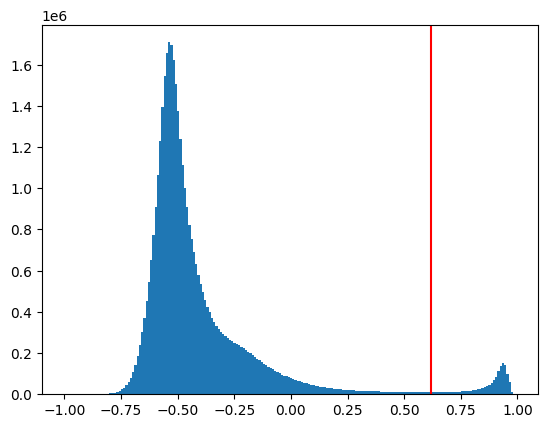

In [99]:
import matplotlib.pyplot as plt
plt.hist(valid.ravel(), bins=200)
plt.axvline(ndsi_thresh, color='r')

In [94]:
# Create binary raster for each mosaic based on NDSI threshold
for f in mosaic_filenames:
    f = Path(f)
    ndsi_filename = out_ndsi / f"{f.stem}_ndsi.tif"
    binary_filename = out_ndsi / f"{f.stem}_binary_ndsi_thresh_0.4.tif"

    with rasterio.open(ndsi_filename) as src:
        ndsi = src.read(1)
        binary_raster = (ndsi > 0.4)

        profile = src.profile
        #profile.update(dtype=rasterio.int32, count=1)

        # write to folder ndsi 
        with rasterio.open(binary_filename, 'w', **profile) as dst:
            dst.write(binary_raster, 1)

for f in mosaic_filenames:
    f = Path(f)
    red_swir_filename = out_red_swir / f"{f.stem}_red_swir_ratio.tif"
    binary_filename = out_red_swir / f"{f.stem}_binary_red_swir_thresh_5.tif"

    with rasterio.open(red_swir_filename) as src:
        red_swir_ratio = src.read(1)
        binary_raster = (red_swir_ratio > 5)

        profile = src.profile
        #profile.update(dtype=rasterio.int32, count=1)

        with rasterio.open(binary_filename, 'w', **profile) as dst:
            dst.write(binary_raster, 1)

In [95]:
# mask the binary rasters with the glacier outlines shapefile
import os
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from scipy.ndimage import median_filter

mask_filename = "/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/glacier_outline/glacier_inventory/SGIhom_1997_v2025.shp"


# Read glacier mask
glacier_mask = gpd.read_file(mask_filename)

for f in mosaic_filenames:
    f = Path(f)
    red_swir_filename = out_red_swir / f"{f.stem}_binary_red_swir_thresh_5.tif"
    masked_filename = out_red_swir / f"{f.stem}_red_swir_ratio_masked_filtered_5.tif"

    with rasterio.open(red_swir_filename) as src:

        # Make sure glacier mask is in same CRS as raster
        glacier_mask_reprojected = glacier_mask.to_crs(src.crs)

        # Mask raster
        masked_array, masked_transform = mask(
            src,
            glacier_mask_reprojected.geometry,
            crop=True,
            nodata=0
        )

        filtered_raster = median_filter(masked_array, size=3)

        # Copy raster metadata
        masked_meta = src.meta.copy()

        # Update metadata for cropped raster
        masked_meta.update({
            "height": masked_array.shape[1],
            "width": masked_array.shape[2],
            "transform": masked_transform,
            "nodata": 0
        })

        # Save
        with rasterio.open(masked_filename, "w", **masked_meta) as dst:
            dst.write(filtered_raster)


In [96]:
# do the same for the NDSI rasters
from scipy.ndimage import median_filter

for f in mosaic_filenames: 
    f = Path(f)
    ndsi_filename = out_ndsi / f"{f.stem}_binary_ndsi_thresh_0.4.tif"
    masked_filename = out_ndsi / f"{f.stem}_binary_ndsi_masked_filtered_0.4.tif"

    with rasterio.open(ndsi_filename) as src:

        # Make sure glacier mask is in same CRS as raster
        glacier_mask_reprojected = glacier_mask.to_crs(src.crs)

        # Mask raster
        masked_array, masked_transform = mask(
            src,
            glacier_mask_reprojected.geometry,
            crop=True,
            nodata=0
        )

        filtered_raster = median_filter(masked_array, size=3)

        # Copy raster metadata
        masked_meta = src.meta.copy()

        # Update metadata for cropped raster
        masked_meta.update({
            "height": masked_array.shape[1],
            "width": masked_array.shape[2],
            "transform": masked_transform,
            "nodata": 0
        })

        # Save
        with rasterio.open(masked_filename, "w", **masked_meta) as dst:
            dst.write(filtered_raster)


In [ ]:
# apply median filter to binary rasters to remove noise
from scipy.ndimage import median_filter

for f in mosaic_filenames:
    f = Path(f)
    binary_filename = out_ndsi / f"{f.stem}_binary_ndsi_masked.tif"
    filtered_filename = out_ndsi / f"{f.stem}_filtered_ndsi.tif"

    with rasterio.open(binary_filename) as src:
        binary_raster = src.read(1)
        filtered_raster = median_filter(binary_raster, size=3)

        profile = src.profile
        #profile.update(dtype=rasterio.int32, count=1)

        with rasterio.open(filtered_filename, 'w', **profile) as dst:
            dst.write(filtered_raster, 1)

# do the same for the red/swir binary rasters
for f in mosaic_filenames:
    f = Path(f)
    binary_filename = out_red_swir / f"{f.stem}_red_swir_ratio_masked.tif"
    filtered_filename = out_red_swir / f"{f.stem}_filtered_red_swir.tif"

    with rasterio.open(binary_filename) as src:
        binary_raster = src.read(1)
        filtered_raster = median_filter(binary_raster, size=3)

        profile = src.profile
        #profile.update(dtype=rasterio.int32, count=1)

        with rasterio.open(filtered_filename, 'w', **profile) as dst:
            dst.write(filtered_raster, 1)
